In [1]:
# 패키지 준비

import io
import zipfile

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

SEED = 42 # 관행적 사용
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


In [6]:
# 데이터 준비

# lab_beijing_step1_data.py
BEIJING_URL = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
STATION = "Aotizhongxin"


def download_beijing_air_quality(station: str = STATION) -> pd.DataFrame:
    """UCI 베이징 대기질 데이터에서 지정한 관측소의 CSV를 DataFrame으로 반환 (35,064행)"""
    response = requests.get(BEIJING_URL, timeout=120) # 웹 요청 (파일 다운로드)
    response.raise_for_status()
    outer = zipfile.ZipFile(io.BytesIO(response.content)) # 압축 해제

    # 바깥 zip 안에 CSV가 바로 있으면 사용, 없으면 안쪽 zip을 한 번 더 연다
    names = outer.namelist()
    for n in names:
        print("---- ------------> ", n)
        if n.endswith(".zip"):
            outer = zipfile.ZipFile(io.BytesIO(outer.read(n)))
            names = outer.namelist()
            break

    csv_name = [n for n in names if n.endswith(".csv") and station in n][0]
    with outer.open(csv_name) as f:
        return pd.read_csv(f)


raw = download_beijing_air_quality()
print(raw.shape)          # (35064, 18)
print(raw.columns.tolist())
# ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
#  'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']
raw.head(5)

---- ------------>  PRSA2017_Data_20130301-20170228.zip
(35064, 18)
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [10]:
# 탐색적 데이터 분석 1

df = raw.copy()
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]]) # 년 + 월 + 일 + 시 -> 하나의 컬럼으로 변경
df = df.set_index("datetime").drop(columns=["No", "year", "month", "day", "hour", "station"])

print(df.index.min(), "~", df.index.max())
# print(df.index.to_series().diff()) # to_series() -> 2차원을 1차원으로 표현
print("시간 간격이 모두 1시간인가?", (df.index.to_series().diff().dropna() == pd.Timedelta("1h")).all())

# 결측치 확인 — Jena 데이터와 달리 거의 모든 컬럼에 결측이 존재
missing = df.isna().sum().to_frame("결측 개수") # isna() -> missingValue 찾기
missing["결측 비율(%)"] = (missing["결측 개수"] / len(df) * 100).round(2)
print(missing)


2013-03-01 00:00:00 ~ 2017-02-28 23:00:00
시간 간격이 모두 1시간인가? True
       결측 개수  결측 비율(%)
PM2.5    925      2.64
PM10     718      2.05
SO2      935      2.67
NO2     1023      2.92
CO      1776      5.07
O3      1719      4.90
TEMP      20      0.06
PRES      20      0.06
DEWP      20      0.06
RAIN      20      0.06
wd        81      0.23
WSPM      14      0.04


PM2.5    1.000000
PM10     0.879104
CO       0.785006
NO2      0.684986
SO2      0.481025
DEWP     0.120112
PRES    -0.005727
RAIN    -0.014004
TEMP    -0.129415
O3      -0.161448
WSPM    -0.278740
Name: PM2.5, dtype: float64


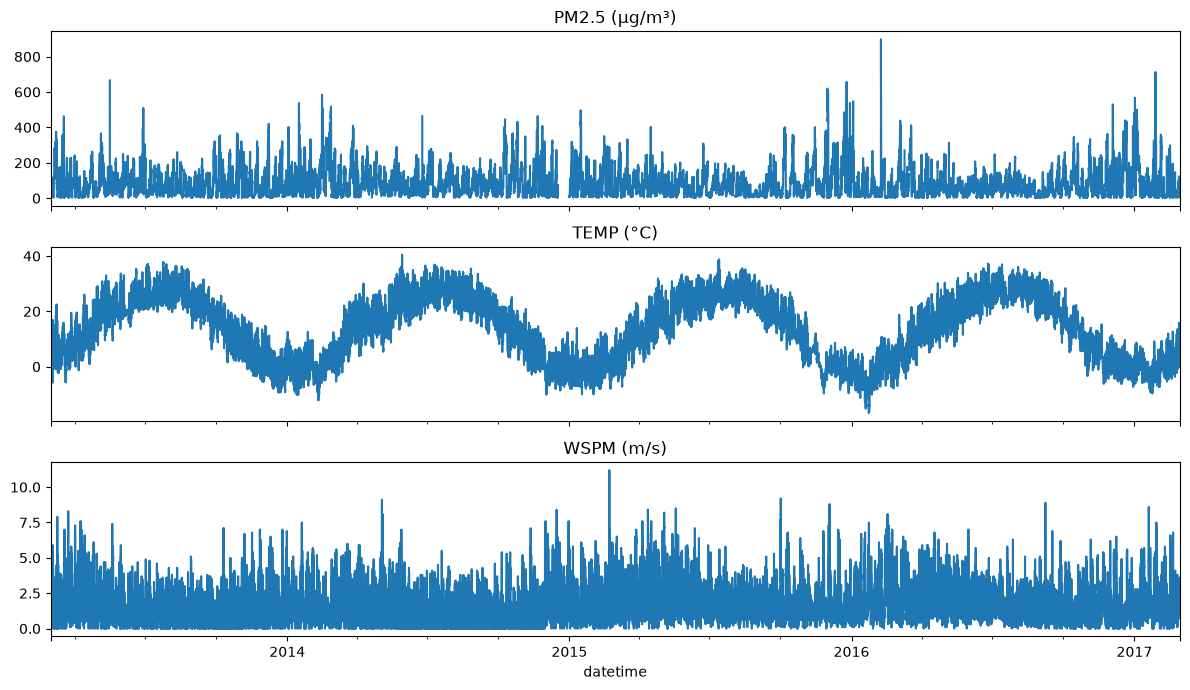

In [ ]:
# 탐색적 데이터 분석 2

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
df["PM2.5"].plot(ax=axes[0], title="PM2.5 (µg/m³)")
df["TEMP"].plot(ax=axes[1], title="TEMP (°C)")
df["WSPM"].plot(ax=axes[2], title="WSPM (m/s)")
plt.tight_layout()
plt.savefig("beijing_raw.png")

# 수치형 변수와 PM2.5의 상관관계
print(df.drop(columns=["wd"]).corr()["PM2.5"].sort_values(ascending=False)) # corr : 상관계수 계산
# → PM10, CO, NO2처럼 함께 배출되는 오염물질은 상관이 높고, 풍속(WSPM)은 음의 상관


In [ ]:
# 데이터 전처리 1 : 보간

num_cols = df.select_dtypes(include="number").columns # 숫자 타입의 컬럼 이름만 뽑기
print(num_cols)
df[num_cols] = df[num_cols].interpolate(method="time").ffill().bfill()
df["wd"] = df["wd"].ffill().bfill()

assert df.isna().sum().sum() == 0 # assert : 조건을 만족하지 못하면 오류 발생
print("결측치 보간 완료")


Index(['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP',
       'RAIN', 'WSPM'],
      dtype='str')
결측치 보간 완료


In [ ]:
# 데이터 전처리 2 : 문자열, 순환형 데이터 처리

WD_DEG = {
    "N": 0, "NNE": 22.5, "NE": 45, "ENE": 67.5,
    "E": 90, "ESE": 112.5, "SE": 135, "SSE": 157.5,
    "S": 180, "SSW": 202.5, "SW": 225, "WSW": 247.5,
    "W": 270, "WNW": 292.5, "NW": 315, "NNW": 337.5,
}

wd_rad = np.deg2rad(df["wd"].map(WD_DEG))
df["wd_sin"] = np.sin(wd_rad)
df["wd_cos"] = np.cos(wd_rad)
df = df.drop(columns=["wd"])

hour, month = df.index.hour, df.index.month
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["month_sin"] = np.sin(2 * np.pi * (month - 1) / 12)
df["month_cos"] = np.cos(2 * np.pi * (month - 1) / 12)
# sin, cos 둘다 쓰는 이유 : 다양한 관점에서 데이터 관측

df.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd_sin,wd_cos,hour_sin,hour_cos,month_sin,month_cos
datetime,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,4.4,-0.382683,0.923880,0.000000,1.000000,0.866025,0.5
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,4.7,0.000000,1.000000,0.258819,0.965926,0.866025,0.5
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,5.6,-0.382683,0.923880,0.500000,0.866025,0.866025,0.5
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,3.1,-0.707107,0.707107,0.707107,0.707107,0.866025,0.5
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,2.0,0.000000,1.000000,0.866025,0.500000,0.866025,0.5


In [15]:
# 입력 / 출력 구분

FEATURE_COLUMNS = df.columns.tolist()
TARGET_COLUMN = "PM2.5"

values = df[FEATURE_COLUMNS].values.astype(np.float32)   # (35064, 17)
target_idx = FEATURE_COLUMNS.index(TARGET_COLUMN)
print(values.shape, "타깃 컬럼 인덱스:", target_idx)
print(FEATURE_COLUMNS)
# ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
#  'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

(35064, 17) 타깃 컬럼 인덱스: 0
['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']


In [16]:
# 입력 - 출력 데이터 구성

WINDOW_SIZE = 24  # 과거 24시간(하루)을 보고 다음 1시간 뒤 PM2.5를 예측


def create_multivariate_windows(data: np.ndarray, target_idx: int, window_size: int):
    """4-9절과 동일 — X: (샘플 수, window_size, 특징 수), y: (샘플 수,)"""
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size, :])
        y.append(data[i + window_size, target_idx])
    return np.array(X), np.array(y)


X, y = create_multivariate_windows(values, target_idx, WINDOW_SIZE)
print(X.shape, y.shape)   # (35040, 24, 17) (35040,)



(35040, 24, 17) (35040,)


In [23]:
# 스케일 조정 ( 정규화 )

# 시간순 분할 (70 / 15 / 15)
n = len(X)
n_train, n_val = int(n * 0.7), int(n * 0.85)

# 스케일러는 훈련 구간 원본 시계열에만 fit — 17개 컬럼 각각의 평균/표준편차를 학습
scaler = StandardScaler() # 평균 0, 표준편차 1 로 만드는 함수
scaler.fit(values[:int(len(values) * 0.7)])


def scale_windows(X_windows):
    shape = X_windows.shape                               # (N, window, 17)
    flat = X_windows.reshape(-1, shape[-1])               # (N*window, 17)
    return scaler.transform(flat).reshape(shape).astype(np.float32)


X_scaled = scale_windows(X)

# 타깃(y)도 같은 스케일러의 PM2.5 컬럼 통계로 정규화 (역변환 시 사용)
y_mean, y_std = scaler.mean_[target_idx], scaler.scale_[target_idx]
y_scaled = ((y - y_mean) / y_std).astype(np.float32)

X_train, y_train = X_scaled[:n_train], y_scaled[:n_train]
X_val, y_val = X_scaled[n_train:n_val], y_scaled[n_train:n_val]
X_test, y_test = X_scaled[n_val:], y_scaled[n_val:]
print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}")
print(f"mean={X_train.mean()} , std={X_train.std()}") # 평균 : mean()


train=24528  val=5256  test=5256
mean=-3.2093362278828863e-06 , std=0.9999380707740784


In [24]:
# DataSet, DataLoader 준비

class MultivariateTimeSeriesDataset(Dataset):
    """4-9절과 동일 — X는 이미 (N, window, 17) 형태이므로 unsqueeze 불필요"""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)   # (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(MultivariateTimeSeriesDataset(X_train, y_train), batch_size=64, shuffle=True)
val_loader = DataLoader(MultivariateTimeSeriesDataset(X_val, y_val), batch_size=64, shuffle=False)
test_loader = DataLoader(MultivariateTimeSeriesDataset(X_test, y_test), batch_size=64, shuffle=False)


In [25]:
class RecurrentForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, cell="rnn"):
        super().__init__()
        rnn_cls = {"rnn": nn.RNN, "lstm": nn.LSTM, "gru": nn.GRU}[cell]
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(hidden_size, 1)   # 4-5절과 동일 — 마지막 은닉 상태 → 다음 값 1개

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.rnn(x)         # LSTM은 (h_n, c_n) 튜플을 반환하지만 여기서는 out만 사용
        return self.fc(out[:, -1, :])  # (batch, 1)


model = RecurrentForecaster(input_size=len(FEATURE_COLUMNS), cell="rnn").to(device)
print(model)
print(f"총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")


RecurrentForecaster(
  (rnn): RNN(17, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
총 파라미터 수: 13,697


In [26]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        pred = model(X_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)   # 기울기 폭주 방지
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        loss = criterion(model(X_batch), y_batch)
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)


def fit(model, save_path, epochs=50, patience=10):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val_loss, patience_counter = float("inf"), 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = eval_epoch(model, val_loader, criterion, device)
        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            torch.save(model.state_dict(), save_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Epoch {epoch}: 조기 종료 (검증 손실 {patience}회 연속 개선 없음)")
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f"[Epoch {epoch:3d}] train_loss={train_loss:.5f}  val_loss={val_loss:.5f}")

    model.load_state_dict(torch.load(save_path))   # 가장 좋았던 가중치로 복원
    return history


history = fit(model, "best_rnn_beijing.pt")


[Epoch   1] train_loss=0.10908  val_loss=0.07954
[Epoch   5] train_loss=0.06142  val_loss=0.06152
[Epoch  10] train_loss=0.05451  val_loss=0.06198
[Epoch  15] train_loss=0.05268  val_loss=0.05869
[Epoch  20] train_loss=0.05169  val_loss=0.05926
[Epoch  25] train_loss=0.04895  val_loss=0.05906
Epoch 26: 조기 종료 (검증 손실 10회 연속 개선 없음)


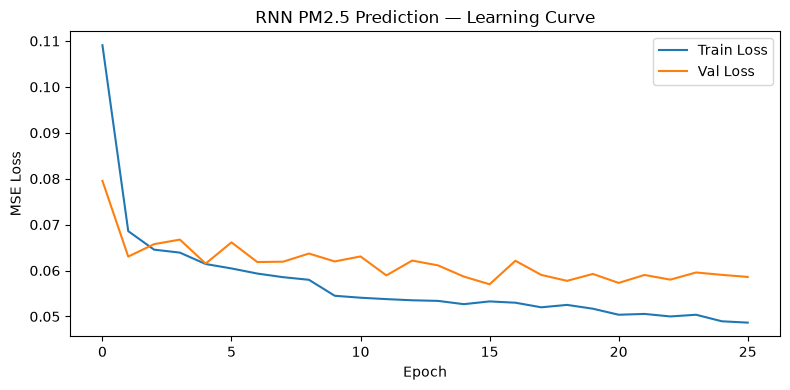

In [27]:
# 학습 과정 시각화

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("RNN PM2.5 Prediction — Learning Curve")
plt.tight_layout()
plt.savefig("rnn_beijing_training_curve.png")

In [29]:
# 모델 평가

@torch.no_grad()
def predict_ugm3(model, X_scaled_windows):
    """정규화된 윈도우 → 실제 단위(µg/m³) 예측값"""
    model.eval()
    X_t = torch.tensor(X_scaled_windows, dtype=torch.float32).to(device)
    pred_scaled = model(X_t).cpu().numpy().reshape(-1)
    return pred_scaled * y_std + y_mean


pred_ugm3 = predict_ugm3(model, X_test)
true_ugm3 = y_test * y_std + y_mean 

rnn_rmse = np.sqrt(mean_squared_error(true_ugm3, pred_ugm3))
rnn_mae = mean_absolute_error(true_ugm3, pred_ugm3)
print(f"RNN  RMSE: {rnn_rmse:.2f} µg/m³   MAE: {rnn_mae:.2f} µg/m³")
print(f"PM2.5 MEAN: {df['PM2.5'].mean():.2f} µg/m³   PM2.5 MAX: {df['PM2.5'].max():.2f} µg/m³  PM2.5 MIN: {df['PM2.5'].min():.2f} µg/m³")


RNN  RMSE: 19.08 µg/m³   MAE: 10.43 µg/m³
PM2.5 MEAN: 82.54 µg/m³   PM2.5 MAX: 898.00 µg/m³  PM2.5 MIN: 3.00 µg/m³


In [30]:
# 모델 평가 2

# 각 테스트 윈도우의 마지막 시점(t) PM2.5 원본 값을 그대로 예측값으로 사용
persist_ugm3 = X[n_val:, -1, target_idx]

persist_rmse = np.sqrt(mean_squared_error(true_ugm3, persist_ugm3))
persist_mae = mean_absolute_error(true_ugm3, persist_ugm3)
print(f"Persistence  RMSE: {persist_rmse:.2f} µg/m³   MAE: {persist_mae:.2f} µg/m³")


Persistence  RMSE: 20.71 µg/m³   MAE: 10.89 µg/m³


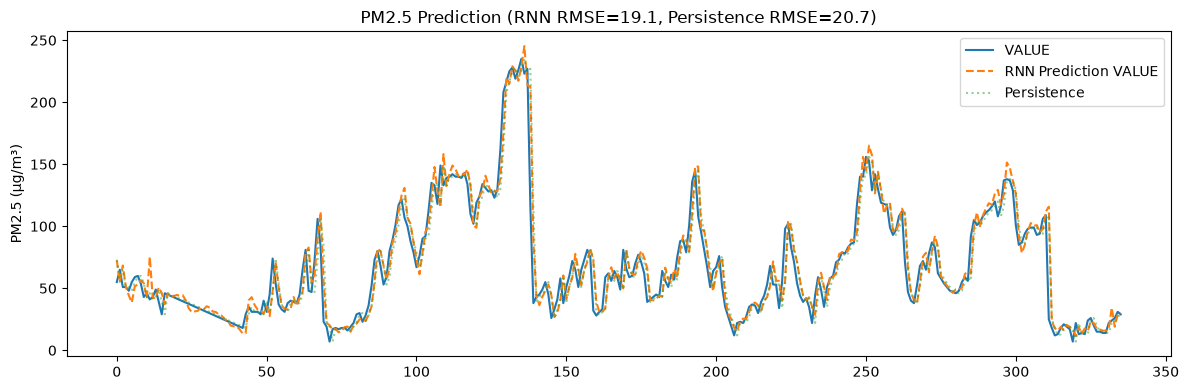

In [31]:
# 예측 결과 시각화

n_show = 24 * 14   # 테스트 구간 앞 2주
plt.figure(figsize=(12, 4))
plt.plot(true_ugm3[:n_show], label="VALUE")
plt.plot(pred_ugm3[:n_show], label="RNN Prediction VALUE", linestyle="--")
plt.plot(persist_ugm3[:n_show], label="Persistence", alpha=0.5, linestyle=":")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.title(f"PM2.5 Prediction (RNN RMSE={rnn_rmse:.1f}, Persistence RMSE={persist_rmse:.1f})")
plt.tight_layout()
plt.savefig("rnn_beijing_prediction_vs_actual.png")
